# Star Schema Analysis — Olist Brazilian E-Commerce

**Source:** `our-project-93971.Extracted_data_star` (clean, dbt-transformed tables)  
**Purpose:** Explore the cleaned star schema to identify a business problem and support analysis

## Star Schema in use
```
fact_order_items  — one row per order line item (revenue, product, seller)
fact_orders       — one row per order (delivery days, review score, payment total)
dim_customers     — who bought (city, state)
dim_products      — what was sold (English category)
dim_sellers       — who sold (city, state)
dim_dates         — when (year, month, quarter, day of week)
```

---
## 0. Setup

In [1]:
# import sys
# print(sys.executable)

In [2]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)

PROJECT   = 'our-project-93971'
DATASET   = 'Extracted_data_star'
PREFIX    = f'`{PROJECT}.{DATASET}'

client = bigquery.Client(project=PROJECT)
print('BigQuery client ready.')

E0000 00:00:1781313300.565570    5766 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1781313300.565640    5766 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1781313300.565646    5766 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1781313300.565649    5766 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1781313300.565651    5766 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


BigQuery client ready.


---
## 1. Star Schema — Row Count Verification

Confirm all 6 tables are present and populated before any analysis.

In [3]:
tables = [
    'fact_order_items',
    'fact_orders',
    'dim_customers',
    'dim_products',
    'dim_sellers',
    'dim_dates',
]

print(f'Star schema row counts ({DATASET}):')
print('-' * 45)
for t in tables:
    result = client.query(
        f'SELECT COUNT(*) AS cnt FROM `{PROJECT}.{DATASET}.{t}`'
    ).result()
    cnt = list(result)[0].cnt
    print(f'  {t:<25} {cnt:>10,} rows')

Star schema row counts (Extracted_data_star):
---------------------------------------------
  fact_order_items             112,650 rows
  fact_orders                   99,441 rows
  dim_customers                 99,441 rows
  dim_products                  32,340 rows
  dim_sellers                    3,095 rows
  dim_dates                      1,096 rows


---
## 2. fact_orders — Overall Order Health

Breakdown by `order_status` to see delivery performance and average review scores.

In [4]:
fact_orders_summary = client.query(f"""
    SELECT
        order_status,
        COUNT(*)                              AS order_count,
        ROUND(AVG(delivery_days), 1)          AS avg_delivery_days,
        ROUND(AVG(estimated_delivery_days), 1) AS avg_estimated_days,
        ROUND(AVG(review_score), 2)           AS avg_review_score,
        ROUND(SUM(total_payment_value), 2)    AS total_revenue
    FROM `{PROJECT}.{DATASET}.fact_orders`
    GROUP BY order_status
    ORDER BY order_count DESC
""").to_dataframe()

display(fact_orders_summary)

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_status,order_count,avg_delivery_days,avg_estimated_days,avg_review_score,total_revenue
0,delivered,96478,12.50,24.40,4.16,"15,422,461.77"
1,shipped,1107,NaN,25.80,2.00,"177,213.96"
2,canceled,625,20.30,23.30,1.80,"143,255.60"
3,unavailable,609,NaN,24.10,1.53,"126,479.51"
4,invoiced,314,NaN,26.00,1.63,"69,137.99"
5,processing,301,NaN,30.50,1.26,"69,394.11"
6,created,5,NaN,27.80,2.33,688.10
7,approved,2,NaN,25.00,2.50,241.08


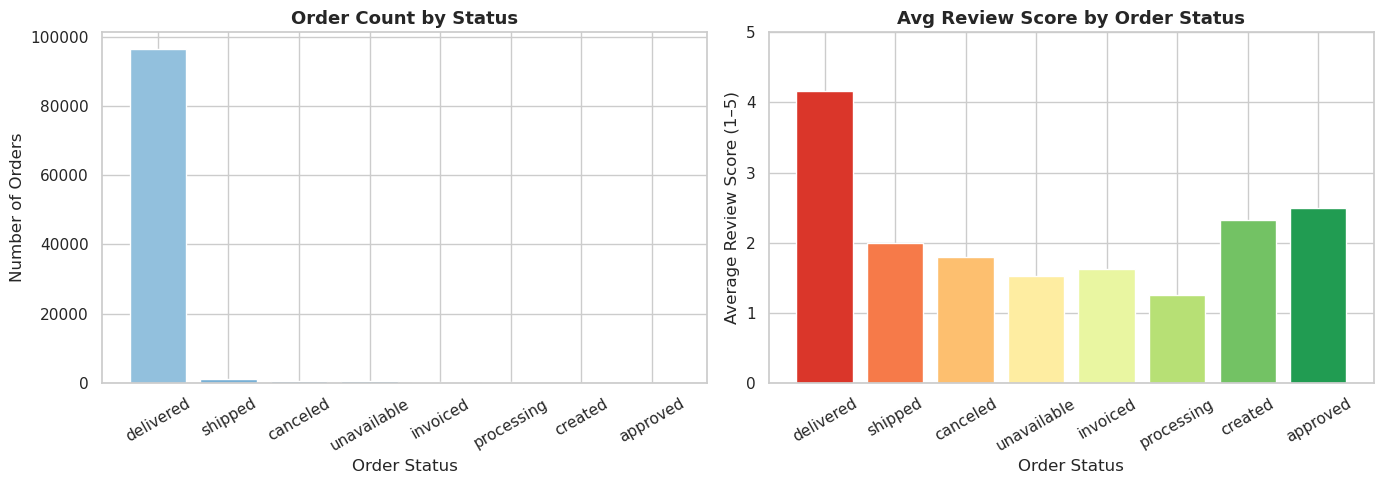

In [5]:
# Order status distribution — bar chart
delivered_only = fact_orders_summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: order count by status
axes[0].bar(
    fact_orders_summary['order_status'],
    fact_orders_summary['order_count'],
    color=sns.color_palette('Blues_d', len(fact_orders_summary))
)
axes[0].set_title('Order Count by Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Order Status')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)

# Right: avg review score by status (delivered orders only, where score exists)
scored = fact_orders_summary.dropna(subset=['avg_review_score'])
axes[1].bar(
    scored['order_status'],
    scored['avg_review_score'],
    color=sns.color_palette('RdYlGn', len(scored))
)
axes[1].set_title('Avg Review Score by Order Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Order Status')
axes[1].set_ylabel('Average Review Score (1–5)')
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 3. Revenue by Product Category

Join `fact_order_items` → `dim_products` to see which categories drive revenue.

In [6]:
revenue_by_category = client.query(f"""
    SELECT
        p.category_name_english,
        COUNT(DISTINCT f.order_id)          AS orders,
        ROUND(SUM(f.total_item_cost), 2)    AS total_revenue,
        ROUND(AVG(f.price), 2)              AS avg_price
    FROM `{PROJECT}.{DATASET}.fact_order_items` f
    JOIN `{PROJECT}.{DATASET}.dim_products` p
      ON f.product_id = p.product_id
    GROUP BY p.category_name_english
    ORDER BY total_revenue DESC
    LIMIT 20
""").to_dataframe()

display(revenue_by_category)

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category_name_english,orders,total_revenue,avg_price
0,health_beauty,8836,"1,441,248.07",130.16
1,watches_gifts,5624,"1,305,541.61",201.14
2,bed_bath_table,9417,"1,241,681.72",93.30
3,sports_leisure,7720,"1,156,656.48",114.34
4,computers_accessories,6689,"1,059,272.40",116.51
5,furniture_decor,6449,"902,511.79",87.56
6,housewares,5884,"778,397.77",90.79
7,cool_stuff,3632,"719,329.95",167.36
8,auto,3897,"685,384.32",139.96
9,garden_tools,3518,"584,219.21",111.63


/tmp/ipykernel_5766/1670169844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


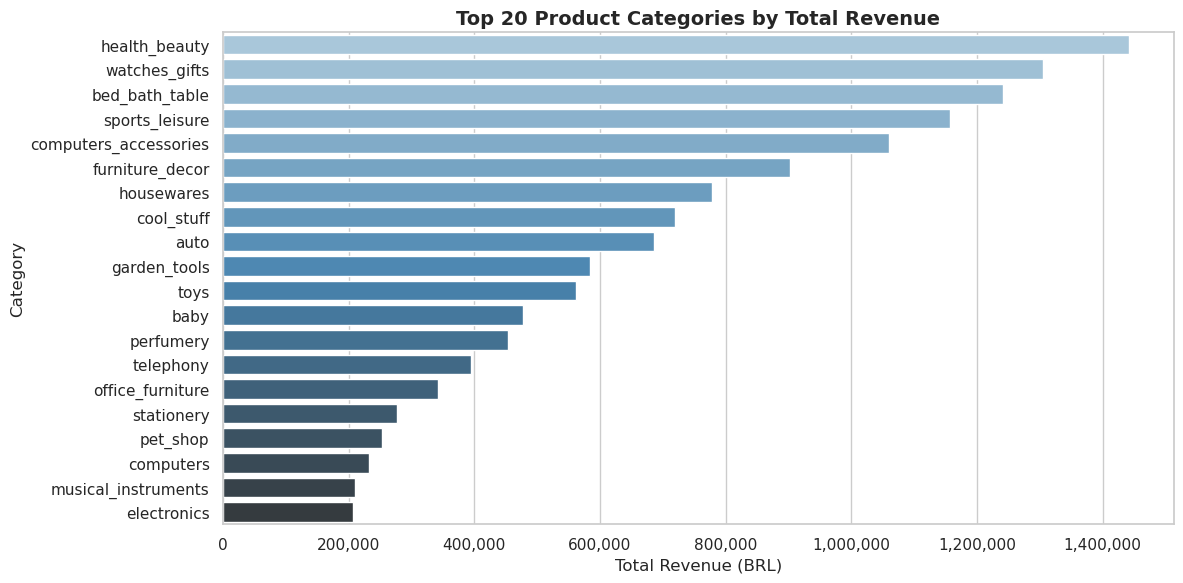

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=revenue_by_category,
    x='total_revenue', y='category_name_english',
    palette='Blues_d', ax=ax
)
ax.set_title('Top 20 Product Categories by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 4. Delivery Performance — Actual vs Estimated

How often are orders delivered late (actual > estimated)? And by how many days?

In [8]:
delivery_perf = client.query(f"""
    SELECT
        delivery_days,
        estimated_delivery_days,
        (delivery_days - estimated_delivery_days) AS delay_days,
        CASE
            WHEN delivery_days <= estimated_delivery_days THEN 'On Time / Early'
            ELSE 'Late'
        END AS delivery_result
    FROM `{PROJECT}.{DATASET}.fact_orders`
    WHERE delivery_days IS NOT NULL
      AND estimated_delivery_days IS NOT NULL
""").to_dataframe()

# Summary
summary = delivery_perf['delivery_result'].value_counts().reset_index()
summary.columns = ['delivery_result', 'count']
summary['pct'] = (summary['count'] / summary['count'].sum() * 100).round(1)
display(summary)

print(f"\nMedian delay (late orders only): {delivery_perf[delivery_perf['delay_days']>0]['delay_days'].median():.1f} days")
print(f"Max late: {delivery_perf['delay_days'].max()} days")

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,delivery_result,count,pct
0,On Time / Early,89941,93.20
1,Late,6535,6.80



Median delay (late orders only): 7.0 days
Max late: 188 days


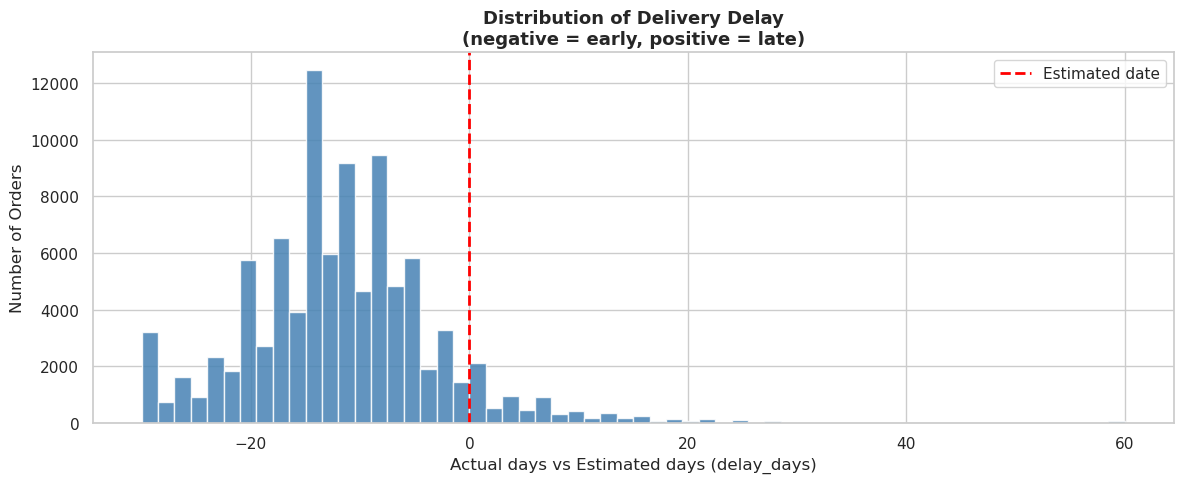

In [9]:
# Distribution of delay_days (capped at -30 to +60 for readability)
clipped = delivery_perf['delay_days'].clip(-30, 60)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(clipped, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linewidth=2, linestyle='--', label='Estimated date')
ax.set_title('Distribution of Delivery Delay\n(negative = early, positive = late)', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual days vs Estimated days (delay_days)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Delivery Delay vs Review Score

**Key business question:** Do late deliveries drive lower review scores?

This query groups by `review_score` and shows average delivery performance for each score band.

In [10]:
delay_vs_review = client.query(f"""
    SELECT
        review_score,
        COUNT(*)                                                      AS order_count,
        ROUND(AVG(delivery_days), 1)                                  AS avg_actual_days,
        ROUND(AVG(estimated_delivery_days), 1)                        AS avg_estimated_days,
        ROUND(AVG(delivery_days - estimated_delivery_days), 1)        AS avg_delay_days,
        ROUND(
            COUNTIF(delivery_days > estimated_delivery_days)
            / COUNT(*) * 100, 1
        )                                                             AS pct_late
    FROM `{PROJECT}.{DATASET}.fact_orders`
    WHERE delivery_days IS NOT NULL
      AND estimated_delivery_days IS NOT NULL
      AND review_score IS NOT NULL
    GROUP BY review_score
    ORDER BY review_score
""").to_dataframe()

display(delay_vs_review)

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,review_score,order_count,avg_actual_days,avg_estimated_days,avg_delay_days,pct_late
0,1,9355,21.30,25.30,-4.00,36.70
1,2,2921,16.60,25.20,-8.60,18.90
2,3,7917,14.20,25.00,-10.80,8.80
3,4,18888,12.20,24.60,-12.40,3.40
4,5,56749,10.60,24.00,-13.40,1.90


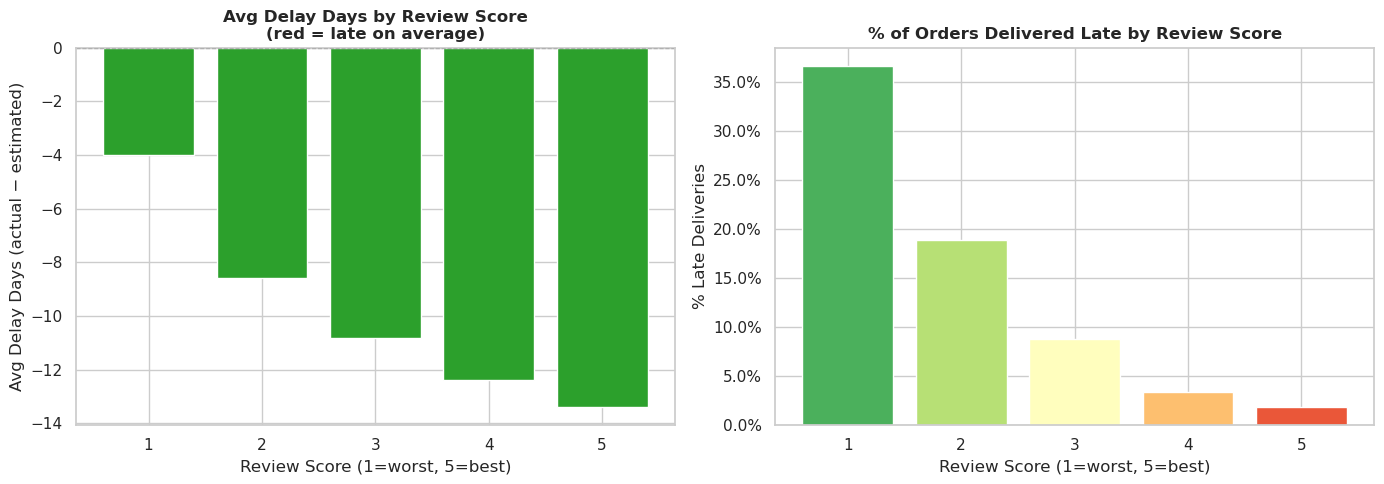

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: avg delay days by review score
colors = ['#d62728' if v > 0 else '#2ca02c' for v in delay_vs_review['avg_delay_days']]
axes[0].bar(delay_vs_review['review_score'], delay_vs_review['avg_delay_days'], color=colors)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Avg Delay Days by Review Score\n(red = late on average)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Review Score (1=worst, 5=best)')
axes[0].set_ylabel('Avg Delay Days (actual − estimated)')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Right: % of orders that arrived late by review score
axes[1].bar(delay_vs_review['review_score'], delay_vs_review['pct_late'],
            color=sns.color_palette('RdYlGn_r', 5))
axes[1].set_title('% of Orders Delivered Late by Review Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Review Score (1=worst, 5=best)')
axes[1].set_ylabel('% Late Deliveries')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

---
## 6. Low Review Score (≤2) Deep Dive

Who are the worst-affected customers? Which states and seller regions produce the most low-score orders?

In [12]:
low_score_by_state = client.query(f"""
    SELECT
        c.state                                           AS customer_state,
        COUNT(*)                                          AS total_orders,
        COUNTIF(o.review_score <= 2)                      AS low_score_orders,
        ROUND(COUNTIF(o.review_score <= 2) / COUNT(*) * 100, 1) AS pct_low_score,
        ROUND(AVG(o.delivery_days), 1)                    AS avg_delivery_days,
        ROUND(AVG(o.delivery_days - o.estimated_delivery_days), 1) AS avg_delay_days
    FROM `{PROJECT}.{DATASET}.fact_orders` o
    JOIN `{PROJECT}.{DATASET}.dim_customers` c
      ON o.customer_id = c.customer_id
    WHERE o.delivery_days IS NOT NULL
      AND o.review_score IS NOT NULL
    GROUP BY c.state
    HAVING total_orders >= 100
    ORDER BY pct_low_score DESC
    LIMIT 15
""").to_dataframe()

display(low_score_by_state)

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,customer_state,total_orders,low_score_orders,pct_low_score,avg_delivery_days,avg_delay_days
0,AL,394,84,21.30,24.40,-8.80
1,MA,712,142,19.90,21.40,-9.70
2,SE,334,63,18.90,21.40,-10.10
3,RJ,12214,2241,18.30,15.20,-11.80
4,PA,933,167,17.90,23.60,-14.20
5,CE,1273,218,17.10,21.10,-10.90
6,BA,3229,549,17.00,19.20,-10.90
7,PI,471,76,16.10,19.40,-11.30
8,PE,1579,234,14.80,18.30,-13.40
9,PB,512,76,14.80,20.20,-13.40


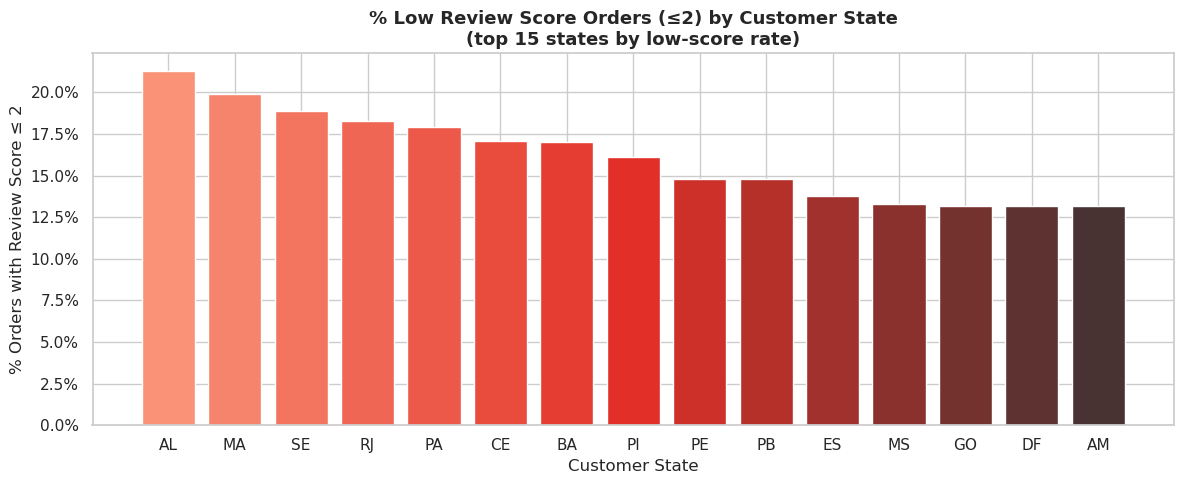

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    low_score_by_state['customer_state'],
    low_score_by_state['pct_low_score'],
    color=sns.color_palette('Reds_d', len(low_score_by_state))
)
ax.set_title('% Low Review Score Orders (≤2) by Customer State\n(top 15 states by low-score rate)', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer State')
ax.set_ylabel('% Orders with Review Score ≤ 2')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

In [14]:
# Low score orders by product category
low_score_by_category = client.query(f"""
    SELECT
        p.category_name_english,
        COUNT(DISTINCT o.order_id)                                       AS total_orders,
        COUNTIF(o.review_score <= 2)                                     AS low_score_orders,
        ROUND(COUNTIF(o.review_score <= 2) / COUNT(DISTINCT o.order_id) * 100, 1) AS pct_low_score,
        ROUND(AVG(o.review_score), 2)                                    AS avg_review_score
    FROM `{PROJECT}.{DATASET}.fact_order_items` f
    JOIN `{PROJECT}.{DATASET}.fact_orders` o
      ON f.order_id = o.order_id
    JOIN `{PROJECT}.{DATASET}.dim_products` p
      ON f.product_id = p.product_id
    WHERE o.review_score IS NOT NULL
    GROUP BY p.category_name_english
    HAVING total_orders >= 100
    ORDER BY pct_low_score DESC
    LIMIT 15
""").to_dataframe()

display(low_score_by_category)

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category_name_english,total_orders,low_score_orders,pct_low_score,avg_review_score
0,office_furniture,1263,438,34.70,3.49
1,fashion_male_clothing,111,37,33.30,3.64
2,fixed_telephony,214,67,31.30,3.68
3,furniture_decor,6398,1597,25.00,3.91
4,construction_tools_safety,166,39,23.50,3.84
5,audio,347,78,22.50,3.83
6,bed_bath_table,9313,2072,22.20,3.90
7,home_confort,395,87,22.00,3.83
8,home_construction,487,107,22.00,3.94
9,computers_accessories,6649,1444,21.70,3.93


---
## 6a. Revenue by Customer State

Total revenue and order count by customer state, joined from `fact_orders` → `dim_customers`.

In [15]:
revenue_by_state = client.query(f"""
    SELECT
        c.state                                        AS customer_state,
        COUNT(DISTINCT o.order_id)                     AS total_orders,
        ROUND(SUM(o.total_payment_value), 2)           AS total_revenue,
        ROUND(AVG(o.total_payment_value), 2)           AS avg_order_value
    FROM `{PROJECT}.{DATASET}.fact_orders` o
    JOIN `{PROJECT}.{DATASET}.dim_customers` c
      ON o.customer_id = c.customer_id
    GROUP BY c.state
    ORDER BY total_revenue DESC
""").to_dataframe()

display(revenue_by_state)

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,customer_state,total_orders,total_revenue,avg_order_value
0,SP,41746,"5,998,226.96",143.69
1,RJ,12852,"2,144,379.69",166.85
2,MG,11635,"1,872,257.26",160.92
3,RS,5466,"890,898.54",162.99
4,PR,5045,"811,156.38",160.78
5,SC,3637,"623,086.43",171.32
6,BA,3380,"616,645.82",182.44
7,DF,2140,"355,141.08",165.95
8,GO,2020,"350,092.31",173.31
9,ES,2033,"325,967.55",160.34


/tmp/ipykernel_5766/2780692124.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


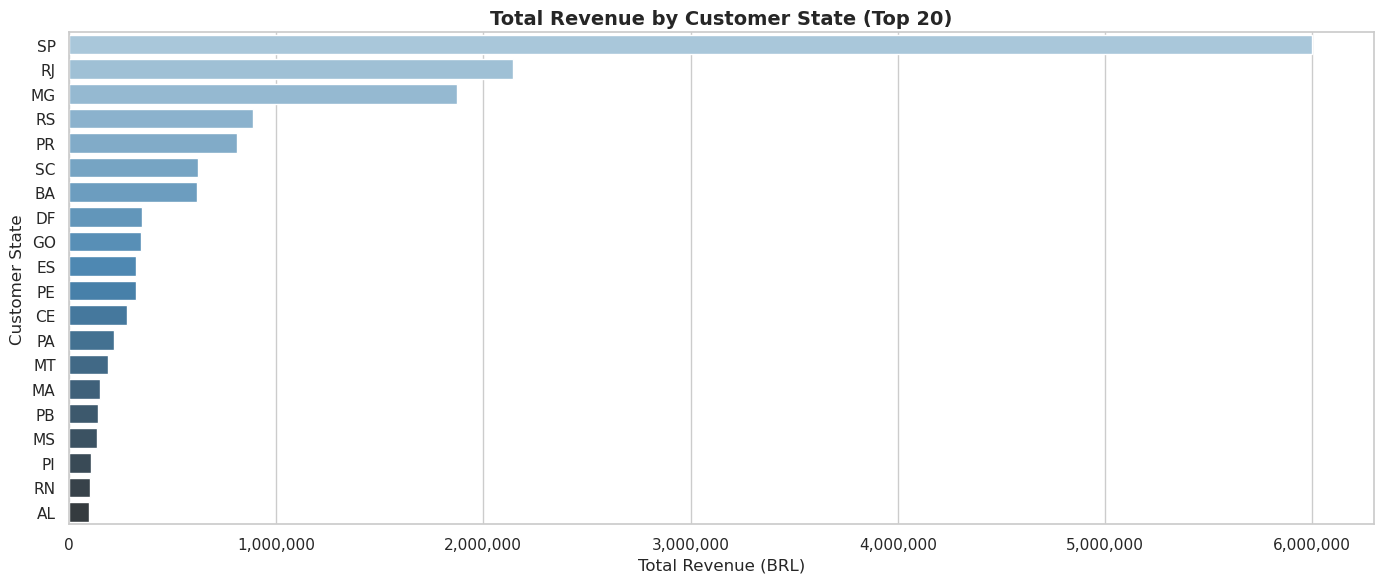

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=revenue_by_state.head(20),
    x='total_revenue', y='customer_state',
    palette='Blues_d', ax=ax
)
ax.set_title('Total Revenue by Customer State (Top 20)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Customer State')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 7. Monthly Trends (clean data)

Revenue and order volume over time using `dim_dates`.

In [17]:
monthly_trends = client.query(f"""
    SELECT
        d.year,
        d.month,
        d.month_name,
        COUNT(DISTINCT f.order_id)        AS order_count,
        ROUND(SUM(f.total_item_cost), 2)  AS total_revenue
    FROM `{PROJECT}.{DATASET}.fact_order_items` f
    JOIN `{PROJECT}.{DATASET}.dim_dates` d
      ON f.purchase_date = d.date_id
    GROUP BY d.year, d.month, d.month_name
    ORDER BY d.year, d.month
""").to_dataframe()

monthly_trends['period'] = monthly_trends['year'].astype(str) + '-' + monthly_trends['month'].astype(str).str.zfill(2)
display(monthly_trends.head(10))

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,year,month,month_name,order_count,total_revenue,period
0,2016,9,September,3,354.75,2016-09
1,2016,10,October,308,"56,808.84",2016-10
2,2016,12,December,1,19.62,2016-12
3,2017,1,January,789,"137,188.49",2017-01
4,2017,2,February,1733,"286,280.62",2017-02
5,2017,3,March,2641,"432,048.59",2017-03
6,2017,4,April,2391,"412,422.24",2017-04
7,2017,5,May,3660,"586,190.95",2017-05
8,2017,6,June,3217,"502,963.04",2017-06
9,2017,7,July,3969,"584,971.62",2017-07


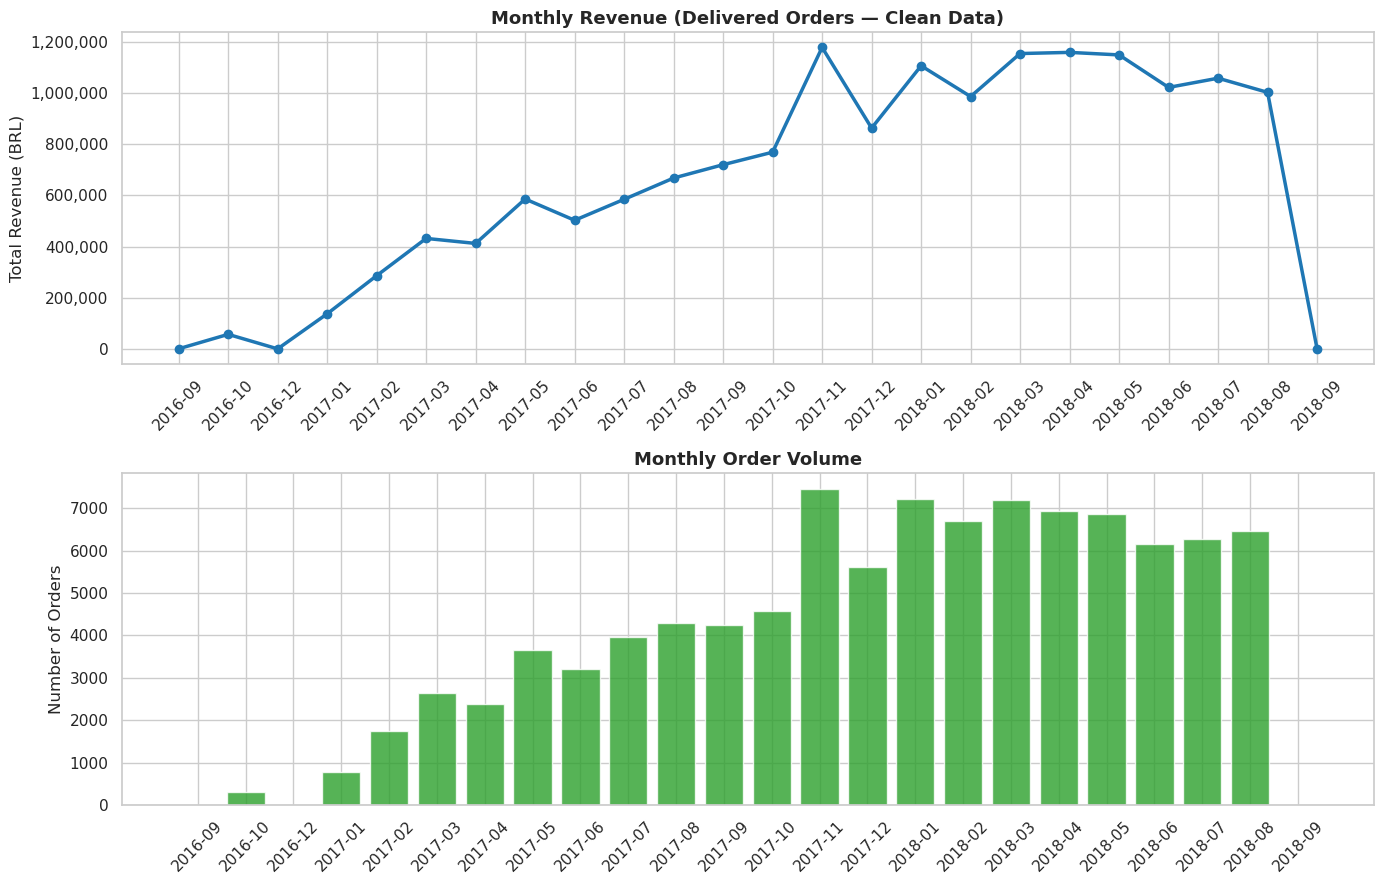

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(monthly_trends['period'], monthly_trends['total_revenue'],
             marker='o', linewidth=2.5, color='#1f77b4')
axes[0].set_title('Monthly Revenue (Delivered Orders — Clean Data)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Revenue (BRL)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].bar(monthly_trends['period'], monthly_trends['order_count'],
            color='#2ca02c', alpha=0.8)
axes[1].set_title('Monthly Order Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 8. Seller Performance — Delivery & Satisfaction

Which seller states produce the most late/poorly-rated deliveries?

In [19]:
seller_perf = client.query(f"""
    SELECT
        s.state                                                           AS seller_state,
        COUNT(DISTINCT f.order_id)                                        AS total_orders,
        ROUND(AVG(o.delivery_days), 1)                                    AS avg_delivery_days,
        ROUND(AVG(o.delivery_days - o.estimated_delivery_days), 1)        AS avg_delay_days,
        ROUND(AVG(o.review_score), 2)                                     AS avg_review_score,
        ROUND(COUNTIF(o.review_score <= 2) / COUNT(DISTINCT f.order_id) * 100, 1) AS pct_low_score
    FROM `{PROJECT}.{DATASET}.fact_order_items` f
    JOIN `{PROJECT}.{DATASET}.fact_orders` o
      ON f.order_id = o.order_id
    JOIN `{PROJECT}.{DATASET}.dim_sellers` s
      ON f.seller_id = s.seller_id
    WHERE o.delivery_days IS NOT NULL
      AND o.review_score IS NOT NULL
    GROUP BY s.state
    HAVING total_orders >= 50
    ORDER BY avg_delay_days DESC
    LIMIT 15
""").to_dataframe()

display(seller_perf)

/home/fionalyh/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,seller_state,total_orders,avg_delivery_days,avg_delay_days,avg_review_score,pct_low_score
0,SP,68169,12.20,-11.30,4.05,17.60
1,MA,385,17.50,-11.40,4.02,16.10
2,RJ,4200,11.90,-12.50,4.16,15.20
3,BA,548,13.70,-12.80,4.16,12.80
4,DF,807,12.40,-13.20,4.07,16.50
5,CE,87,17.90,-13.40,4.28,11.50
6,RN,51,12.90,-13.50,4.27,11.80
7,MG,7682,12.60,-13.60,4.16,13.90
8,ES,306,12.70,-13.60,4.07,17.00
9,SC,3584,13.50,-14.20,4.13,15.30


---
## 9. Business Problem Statement

Based on the analysis above, fill in your team's chosen business problem below.

---

### Problem Statement

> **To be decided by the team based on the charts above.**
>
> Suggested option: *"A significant proportion of Olist orders receive low customer review scores (≤2). The data shows that late deliveries are strongly correlated with poor satisfaction. We want to understand which factors — delivery delay, product category, seller location, or customer region — most predict a low review score, and identify where intervention would have the greatest impact."*

---

### Success Metrics

| Metric | Current baseline | Target |
|---|---|---|
| % orders with review score ≤ 2 | (run Section 5 query) | Reduce by X% |
| Average delivery delay (days) | (run Section 4 query) | Reduce to ≤ 0 days |
| % orders delivered late | (run Section 4 query) | Reduce by X% |

---

### How to track
- Use `fact_orders` (`review_score`, `delivery_days`, `estimated_delivery_days`) as the primary tracking table
- Segment by `dim_customers.state`, `dim_sellers.state`, `dim_products.category_name_english`
- Use `dim_dates` to track trend over time (monthly rollup)